# 1.1 Cleaning data

In [1]:
import yfinance as yf
import pandas as pd

# Define the ticker symbol for e.g. Tesla
ticker_symbol = 'TSLA'

# Fetch historical data from Yahoo Finance
stock_data = yf.download(ticker_symbol, period="max", auto_adjust=False)

if stock_data.empty:
    raise ValueError(f"No data returned for {ticker_symbol} - check ticker again!")

# Move Date out of the index into a normal column
# .reset_index() to re-index the data frame
stock_data = stock_data.reset_index()

# Save a CSV copy (index=False avoids writing an unnamed index column)
stock_data.to_csv('stock_historical_data.csv', index=False)

df = pd.read_csv('stock_historical_data.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

# drop rows with empty data
df.dropna(inplace=True)

print(df.head())


[*********************100%***********************]  1 of 1 completed


        Date           Adj Close               Close                High  \
1 2010-06-29  1.5926669836044312  1.5926669836044312  1.6666669845581055   
2 2010-06-30  1.5886670351028442  1.5886670351028442  2.0280001163482666   
3 2010-07-01  1.4639999866485596  1.4639999866485596  1.7280000448226929   
4 2010-07-02  1.2799999713897705  1.2799999713897705  1.5399999618530273   
5 2010-07-06  1.0740000009536743  1.0740000009536743  1.3333330154418945   

                  Low                Open     Volume  
1  1.1693329811096191  1.2666670083999634  281494500  
2   1.553333044052124  1.7193330526351929  257806500  
3  1.3513330221176147  1.6666669845581055  123282000  
4    1.24733304977417  1.5333329439163208   77097000  
5  1.0553330183029175  1.3333330154418945  103003500  


# 1.2 Preparing the Random Forest Model

In [17]:
from sklearn.model_selection import train_test_split

# Features: today's OHLCV
x = df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']] #inputs
y = df[['Open', 'High', 'Low', 'Close']].shift(-1) #stuff to predict
# .shift(-1) so that e.g. row 100 of y will hold row 101's prices
# so that y will be prediction of tomorrow's prices, not prediction of today's prices (which makes no sense)

# The last row now has no data, so drop it
x = x.iloc[:-1]
y = y.iloc[:-1]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=False)
# shuffle=False preserves time order

print(x_train.dtypes)

Open         object
High         object
Low          object
Close        object
Adj Close    object
Volume       object
dtype: object


# 1.3 Train model

In [18]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)


RandomForestRegressor(random_state=42)

# 1.4 Evaluate model

<b>MAE</b> — the average number of dollars each next-day prediction for (Open/High/Low/Close) was off from the actual price, across all dates in the test set (20%).

<b>MSE</b> — the average squared dollar error for that target across the test set, weighting large misses much more heavily than small ones.

<b>R^2</b> — the proportion (0 to 1) of that target's price variation across the test set that the model's predictions account for.

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_predict = model.predict(x_test)
targets = ['Open', 'High', 'Low', 'Close']
metrics = []

for i, name in enumerate(targets):
    mae = mean_absolute_error(y_test.iloc[:, i], y_predict[:, i])
    mse = mean_squared_error(y_test.iloc[:, i], y_predict[:, i])
    r2  = r2_score(y_test.iloc[:, i], y_predict[:, i])
    metrics.append({'Target': name, 'MAE': mae, 'MSE': mse, 'R^2': r2})

metrics_df = pd.DataFrame(metrics).set_index("Target").round(4)
print(metrics_df)


            MAE       MSE     R^2
Target                           
Open    11.0999  379.6839  0.9531
High    12.3453  395.5678  0.9527
Low     12.9030  408.1205  0.9475
Close   14.2656  466.1265  0.9422


# 1.5 Visualise the Evaluation

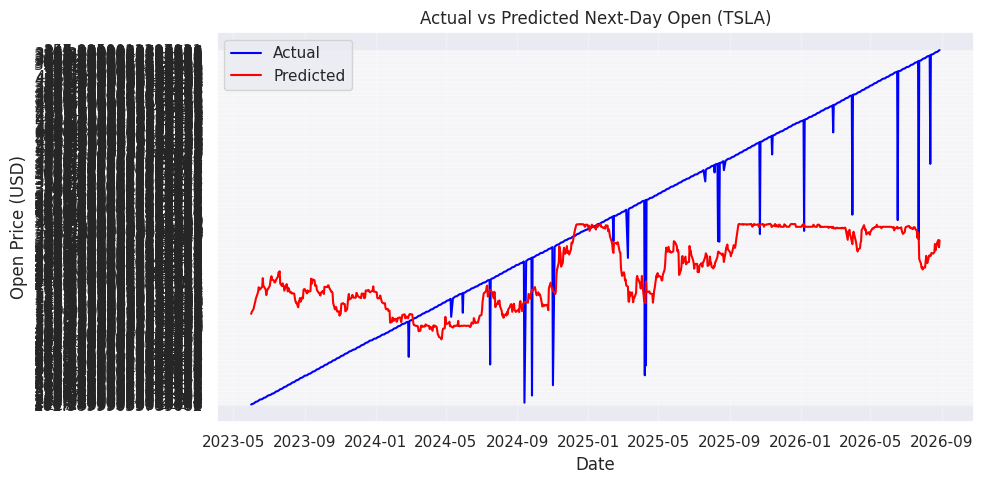

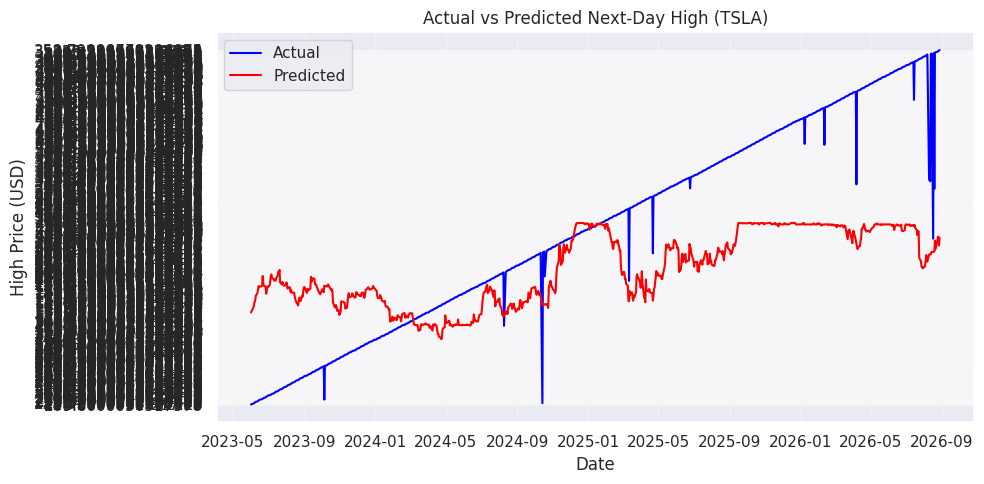

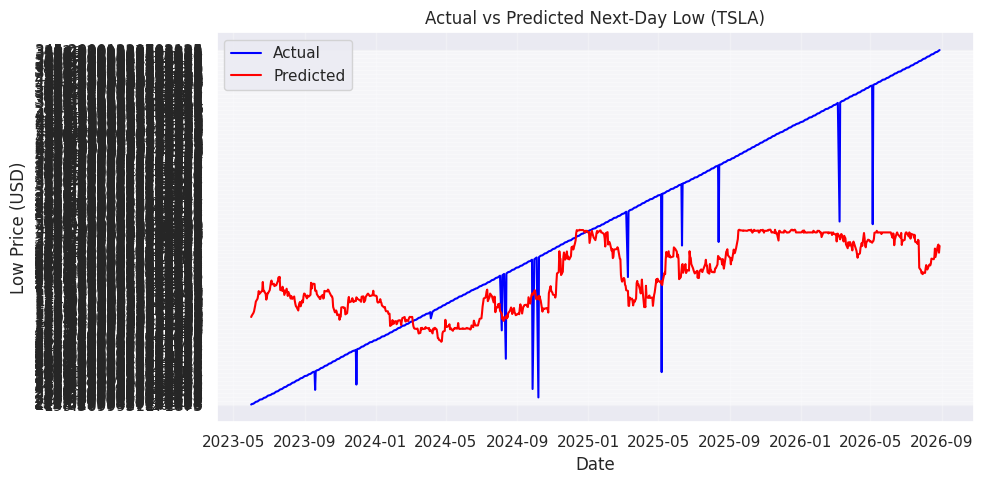

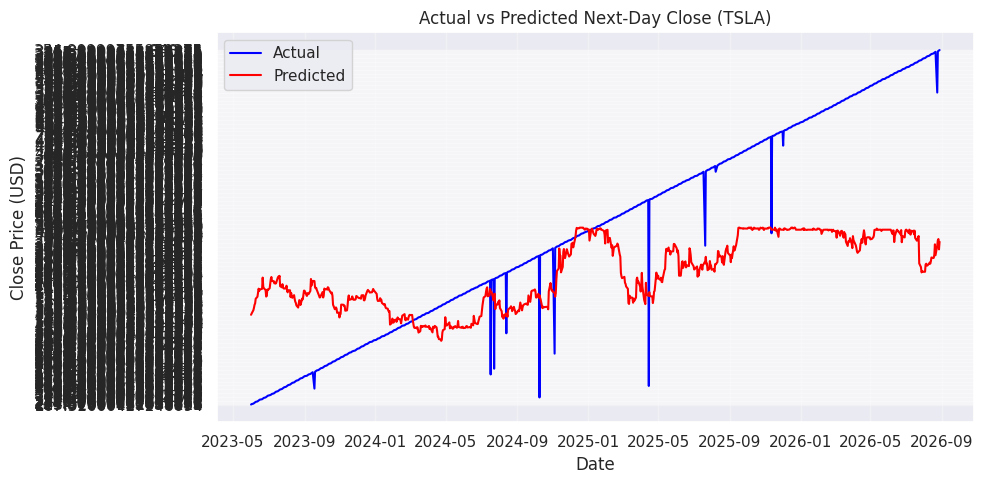

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sea; sea.set()

#New dataframe for test set and predictions
target_dates = df['Date'].shift(-1).loc[y_test.index]
df_test = df.loc[y_test.index].copy()
df_test['Date'] = target_dates.values

#Add to new test dataframe
df_test['Predicted Open'] = y_predict[:,0]
df_test['Actual Open'] = y_test['Open'].values

df_test['Predicted High'] = y_predict[:,1]
df_test['Actual High'] = y_test['High'].values

df_test['Predicted Low'] = y_predict[:,2]
df_test['Actual Low'] = y_test['Low'].values

df_test['Predicted Close'] = y_predict[:,3]
df_test['Actual Close'] = y_test['Close'].values

def plot_graph(df, property, actual, prediction):
    plt.figure(figsize=(10, 5))
    plt.plot(df_test['Date'], df_test[actual], color='blue', label='Actual')
    plt.plot(df_test['Date'], df_test[prediction], color='red', label='Predicted')
    plt.title(f'Actual vs Predicted Next-Day {property} ({ticker_symbol})')
    plt.xlabel('Date')
    plt.ylabel(f'{property} Price (USD)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_graph(df_test, 'Open', 'Actual Open', 'Predicted Open')
plot_graph(df_test, 'High', 'Actual High', 'Predicted High')
plot_graph(df_test, 'Low', 'Actual Low', 'Predicted Low')
plot_graph(df_test, 'Close', 'Actual Close', 'Predicted Close')

# 1.6 Predict tomorrow's price

In [6]:
from datetime import datetime

latest_data = df.iloc[-1]

next_day_input = {
    'Open': latest_data['Open'],
    'High': latest_data['High'],
    'Low': latest_data['Low'],
    'Close': latest_data['Close'],
    'Adj Close': latest_data['Adj Close'],
    'Volume': latest_data['Volume']
}

next_day_df = pd.DataFrame([next_day_input])
latest_date = latest_data['Date']
results = model.predict(next_day_df)

items = ['Open', 'High', 'Low', 'Close']
print(f'Predictions for the trading day after {latest_date}')
for i in range(4):
    print(f"Predicted {items[i]}: ${results[0][i]:.2f}")


Predictions for the trading day after 2026-08-28 00:00:00
Predicted Open: $355.95
Predicted High: $364.16
Predicted Low: $347.43
Predicted Close: $357.28
